Dimensionless parameter:
kappa = 0.8
phihat_true  = -1.0880339146912879 v_true  = -1.6366381483332257
phihat_false = 0.8788850662499729 v_false = -0.045107919927235444 Delta v = 1.5915302284059902
phihat_top   = 0.2091488484413166 v_top = 0.2817460682604612
phihat(0) = -1.0854016881830713


/tmp/ipykernel_245244/3647460269.py:123: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return 2.0 * np.pi**2 * np.trapz(integrand * rhat**3, rhat)


Dimensionless action s4_hat = 311.72590916843654


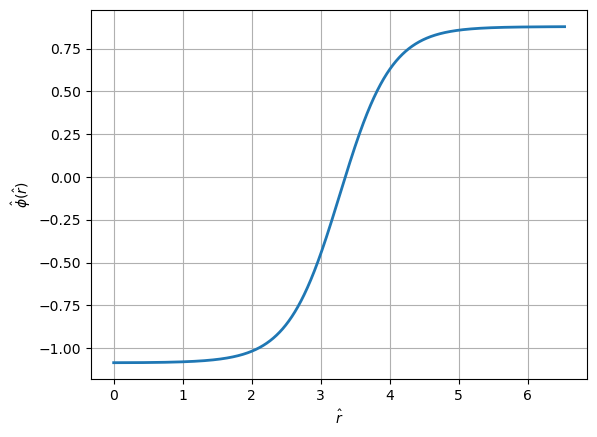

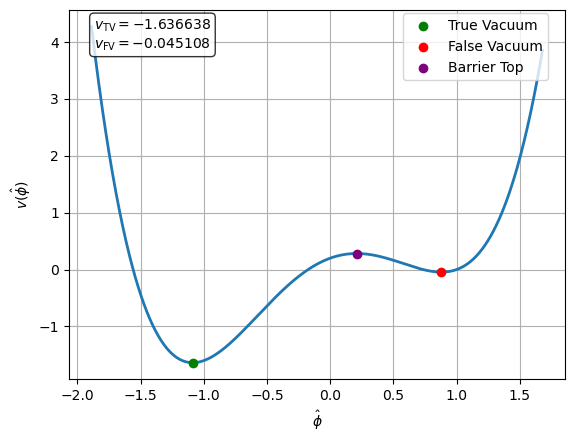

Runtime: 23.074955 seconds


In [1]:
#!/usr/bin/env python3

# _______________________ A1) Overshoot/undershoot shooting (dimensionless Coleman) _______________________
import time
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import root_scalar
import matplotlib.pyplot as plt


# ---------------- Dimensionless potential v(\hat{phi}) ----------------
# \hat{phi} = phi/a
# v(\hat{phi}) = V / (lambda a^4 / 8)
#              = (\hat{phi}^2 - 1)^2 + kappa (\hat{phi} - 1)
# with kappa = 4 eps / (lambda a^4)

def v(phihat, kappa):
    return (phihat**2 - 1.0)**2 + kappa * (phihat - 1.0)

def dv(phihat, kappa):
    return 4.0 * phihat * (phihat**2 - 1.0) + kappa

def d2v(phihat, kappa):
    return 12.0 * phihat**2 - 4.0


# ---------------- Robust vacua finder ----------------
def find_stationary_points(dvfun, args, phi_min, phi_max, n_scan=6000):
    ph = np.linspace(phi_min, phi_max, n_scan + 1)
    f = dvfun(ph, *args)
    roots = []
    for i in range(n_scan):
        f1, f2 = f[i], f[i + 1]
        if not np.isfinite(f1) or not np.isfinite(f2):
            continue
        if f1 == 0.0:
            br = (ph[i] - 1e-3, ph[i] + 1e-3)
        elif f1 * f2 < 0:
            br = (ph[i], ph[i + 1])
        else:
            continue
        try:
            sol = root_scalar(lambda x: dvfun(x, *args), bracket=br, method="brentq", xtol=1e-14)
            roots.append(sol.root)
        except Exception:
            pass
    roots = np.array(sorted(roots))
    uniq = []
    for r in roots:
        if not uniq or abs(r - uniq[-1]) > 1e-6:
            uniq.append(r)
    return np.array(uniq)

def find_vacua(vfun, dvfun, d2vfun, args, phi_min, phi_max):
    stat = find_stationary_points(dvfun, args, phi_min, phi_max)
    mins = []
    for x in stat:
        if d2vfun(x, *args) > 0:
            mins.append((x, vfun(x, *args)))
    if len(mins) < 2:
        raise RuntimeError("Need at least two minima (true + false).")
    mins.sort(key=lambda t: t[1])
    (phi_true, v_true), (phi_false, v_false) = mins[0], mins[1]
    return phi_true, phi_false, v_true, v_false

def find_barrier_top(dvfun, d2vfun, args, phi_min, phi_max):
    stat = find_stationary_points(dvfun, args, phi_min, phi_max)
    tops = [x for x in stat if d2vfun(x, *args) < 0]
    if not tops:
        return None
    tops = sorted(tops)
    return tops[len(tops) // 2]


# ---------------- Bounce ODE & action ----------------
# Using dimensionless radius \hat{r}
# Equation: \hat{phi}'' + (3/\hat{r}) \hat{phi}' = dv/d\hat{phi}

def bounce_ode(rhat, y, dvfun, args):
    phihat, dphihat = y
    fric = 0.0 if rhat == 0.0 else 3.0 / rhat
    return [dphihat, dvfun(phihat, *args) - fric * dphihat]

def solve_bounce(phi0, rhat_max, dvfun, args, nsteps=4000):
    r0 = 1e-6
    sol = solve_ivp(
        lambda rhat, y: bounce_ode(rhat, y, dvfun, args),
        (r0, rhat_max),
        [phi0, 0.0],
        max_step=rhat_max / nsteps,
        rtol=1e-9,
        atol=1e-12
    )
    return sol.t, sol.y[0], sol.y[1]

def shoot_F(phi0, rhat_max, dvfun, args, phi_false):
    rhat, phihat, dphihat = solve_bounce(phi0, rhat_max, dvfun, args)
    return phihat[-1] - phi_false

def find_phi0(phi_true, phi_false, rhat_max, dvfun, args):
    delta = 1e-4
    lo = phi_true + delta
    hi = phi_false - delta
    grid = np.linspace(lo, hi, 80)
    F = np.array([shoot_F(x, rhat_max, dvfun, args, phi_false) for x in grid])
    br = None
    for i in range(len(grid) - 1):
        if F[i] * F[i + 1] < 0:
            br = (grid[i], grid[i + 1])
            break
    if br is None:
        raise RuntimeError("No sign change in shooting function; increase rhat_max or widen scan window.")
    sol = root_scalar(
        lambda x: shoot_F(x, rhat_max, dvfun, args, phi_false),
        bracket=br,
        method="brentq",
        xtol=1e-10
    )
    return sol.root

def action_s4_dimless(rhat, phihat, dphihat, vfun, args, v_false):
    integrand = 0.5 * dphihat**2 + vfun(phihat, *args) - v_false
    return 2.0 * np.pi**2 * np.trapz(integrand * rhat**3, rhat)


def main():
    # ---- original dimensionful parameters ----
    lam = 0.5
    a   = 1.0
    eps = 0.1

    # ---- dimensionless parameter ----
    kappa = 4.0 * eps / (lam * a**4)
    args = (kappa,)

    print("Dimensionless parameter:")
    print("kappa =", kappa)

    # ---- find vacua in terms of \hat{phi} ----
    phihat_min, phihat_max = -3.0, 3.0
    phihat_true, phihat_false, v_true, v_false = find_vacua(v, dv, d2v, args, phihat_min, phihat_max)
    top = find_barrier_top(dv, d2v, args, phihat_min, phihat_max)

    print("phihat_true  =", phihat_true,  "v_true  =", v_true)
    print("phihat_false =", phihat_false, "v_false =", v_false, "Delta v =", v_false - v_true)
    if top is not None:
        print("phihat_top   =", top, "v_top =", v(top, *args))

    # ---- choose \hat{r}_max from false vacuum curvature ----
    mf2_hat = d2v(phihat_false, *args)
    if mf2_hat <= 0:
        raise RuntimeError("False vacuum not stable (dimensionless m_f^2 <= 0).")
    rhat_max = 15.0 / np.sqrt(mf2_hat)

    # ---- shooting for \hat{phi}(0) ----
    phi0 = find_phi0(phihat_true, phihat_false, rhat_max, dv, args)
    print("phihat(0) =", phi0)

    rhat, phihat_r, dphihat_r = solve_bounce(phi0, rhat_max, dv, args)
    s4_hat = action_s4_dimless(rhat, phihat_r, dphihat_r, v, args, v_false)
    print("Dimensionless action s4_hat =", s4_hat)

    # ---- plot bounce profile ----
    plt.figure()
    plt.plot(rhat, phihat_r, lw=2)
    plt.xlabel(r"$\hat{r}$")
    plt.ylabel(r"$\hat{\phi}(\hat{r})$")
    plt.grid(True)

    # ---- plot dimensionless potential ----
    phihat = np.linspace(min(phihat_true, phihat_false) - 0.8,
                         max(phihat_true, phihat_false) + 0.8, 800)

    plt.figure()
    plt.plot(phihat, v(phihat, *args), lw=2)

    plt.scatter([phihat_true], [v_true], color='green', zorder=3, label='True Vacuum')
    plt.scatter([phihat_false], [v_false], color='red', zorder=3, label='False Vacuum')

    if top is not None:
        plt.scatter([top], [v(top, *args)],
                    color='purple', zorder=3, label='Barrier Top')

    plt.xlabel(r"$\hat{\phi}$")
    plt.ylabel(r"$v(\hat{\phi})$")
    plt.grid(True)

    ax = plt.gca()

    # legend box: top-right
    ax.legend(loc='upper right', bbox_to_anchor=(0.98, 1.01))

    # values box: top-left
    info_text = (
        rf"$v_{{\mathrm{{TV}}}} = {v_true:.6f}$" "\n"
        rf"$v_{{\mathrm{{FV}}}} = {v_false:.6f}$"
    )

    ax.text(
        0.05, 0.98,
        info_text,
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment='top',
        horizontalalignment='left',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='black')
    )

    plt.show()


if __name__ == "__main__":
    start = time.perf_counter()
    main()
    end = time.perf_counter()
    print(f"Runtime: {end - start:.6f} seconds")

kappa = 0.033862433862433865
phihat_true  = -1.0042062284866318 v_true  = -0.06779623344105781
phihat_false = 0.9957400131897902 v_false = -7.197247402326997e-05 Delta v = 0.06772426096703454
phihat_top  = 0.008466215296841351 v_top   = 0.9662809043277794
Dimensionless S4 = 5420193.452806445


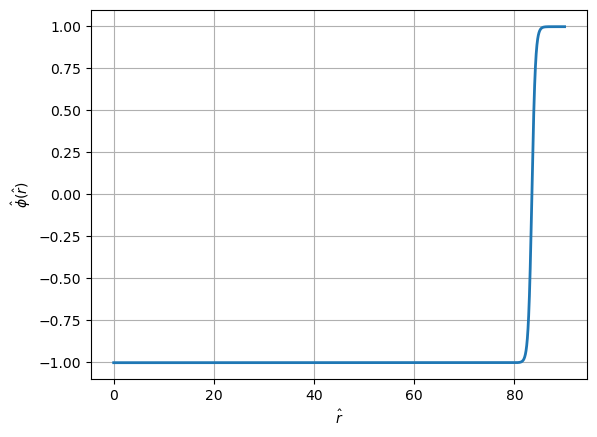

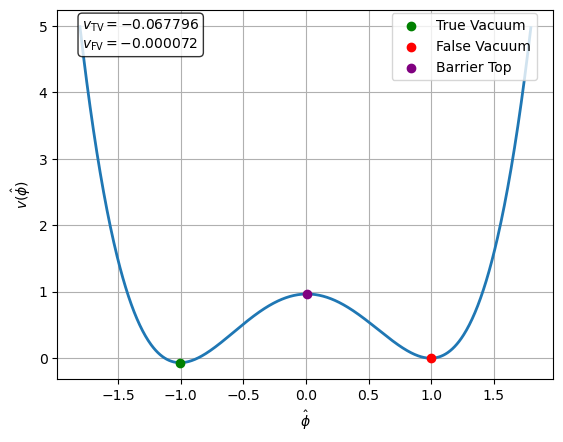

Runtime: 1.197958 seconds


In [9]:
#!/usr/bin/env python3
# _______________________ A2) SingleFieldInstanton (1D) for dimensionless Coleman potential _______________________
import time
import numpy as np
import matplotlib.pyplot as plt
from cosmoTransitions.tunneling1D import SingleFieldInstanton, PotentialError

# ---------------- Dimensionless potential ----------------
# \hat{\phi} = \phi / a
# v(\hat{\phi}) = U / (\lambda a^4 / 8)
#               = (\hat{\phi}^2 - 1)^2 + kappa (\hat{\phi} - 1)
# where kappa = 4 eps / (lambda a^4)

def v(phihat, kappa):
    return (phihat**2 - 1.0)**2 + kappa * (phihat - 1.0)

def dv(phihat, kappa):
    return 4.0 * phihat * (phihat**2 - 1.0) + kappa

def d2v(phihat, kappa):
    return 12.0 * phihat**2 - 4.0

# ---------------- Robust vacua finder (analytic cubic) ----------------
def find_vacua_cubic_dimless(kappa, tol_im=1e-10):
    """
    dv/dphihat = 4 phihat (phihat^2 - 1) + kappa = 0
               => phihat^3 - phihat + kappa/4 = 0
    Solve cubic, pick the two minima via d2v > 0, then label by potential depth.
    """
    coeffs = [1.0, 0.0, -1.0, kappa / 4.0]
    roots = np.roots(coeffs)
    real_roots = np.real(roots[np.abs(np.imag(roots)) < tol_im])

    if len(real_roots) < 3:
        raise RuntimeError("Cubic did not return 3 real stationary points; metastability may be lost.")

    minima = []
    maxima = []
    for r in real_roots:
        if d2v(r, kappa) > 0:
            minima.append((r, v(r, kappa)))
        else:
            maxima.append((r, v(r, kappa)))

    if len(minima) < 2:
        raise RuntimeError("Less than two minima found; no false vacuum.")

    minima.sort(key=lambda t: t[1])
    (phihat_true, v_true), (phihat_false, v_false) = minima[0], minima[1]

    phihat_top = None
    if maxima:
        lo, hi = sorted([phihat_true, phihat_false])
        between = [x for x, _ in maxima if lo < x < hi]
        if between:
            phihat_top = between[0]
        else:
            phihat_top = sorted([x for x, _ in maxima])[len(maxima) // 2]

    return phihat_true, phihat_false, v_true, v_false, phihat_top

def main():
    # ---- original dimensionful parameters ----
    lam = 0.7
    a   = 1.5
    eps = 0.03
    
    

    # ---- dimensionless parameter ----
    kappa = 4.0 * eps / (lam * a**4)
    print("kappa =", kappa)

    # ---- find vacua for dimensionless potential ----
    phihat_true, phihat_false, v_true, v_false, phihat_top = find_vacua_cubic_dimless(kappa)

    print("phihat_true  =", phihat_true,  "v_true  =", v_true)
    print("phihat_false =", phihat_false, "v_false =", v_false, "Delta v =", v_false - v_true)
    if phihat_top is not None:
        print("phihat_top  =", phihat_top, "v_top   =", v(phihat_top, kappa))

    # ---- SingleFieldInstanton ----
    try:
        inst = SingleFieldInstanton(
            phi_absMin=phihat_true,      # true vacuum in dimensionless variable
            phi_metaMin=phihat_false,    # false vacuum in dimensionless variable
            V=lambda x: v(x, kappa),
            dV=lambda x: dv(x, kappa),
            d2V=lambda x: d2v(x, kappa),
            alpha=3                      # O(4)
        )
    except PotentialError as e:
        print("PotentialError:", e)
        return

    prof = inst.findProfile(xtol=1e-10, phitol=1e-10)
    S4_hat = inst.findAction(prof)
    print("Dimensionless S4 =", S4_hat)

    rhat = np.array(prof.R)
    phihat_r = np.array(prof.Phi)

    # ---- plot bounce profile ----
    plt.figure()
    plt.plot(rhat, phihat_r, lw=2)
    plt.xlabel(r"$\hat{r}$")
    plt.ylabel(r"$\hat{\phi}(\hat{r})$")
  #  plt.title("Bounce profile (SingleFieldInstanton, dimensionless potential)")
    plt.grid(True)
   # plt.savefig("fieldprofile.png", dpi=300, bbox_inches="tight")
    # ---- plot dimensionless potential ----
    phihat = np.linspace(min(phihat_true, phihat_false) - 0.8,
                         max(phihat_true, phihat_false) + 0.8, 800)

    plt.figure()
    plt.plot(phihat, v(phihat, kappa), lw=2)

    plt.scatter([phihat_true],  [v_true],  color='green',  zorder=3, label='True Vacuum')
    plt.scatter([phihat_false], [v_false], color='red',    zorder=3, label='False Vacuum')

    if phihat_top is not None:
        plt.scatter([phihat_top], [v(phihat_top, kappa)],
                color='purple', zorder=3, label='Barrier Top')

    plt.xlabel(r"$\hat{\phi}$")
    plt.ylabel(r"$v(\hat{\phi})$")
    plt.grid(True)

    ax = plt.gca()

    # legend box: top-right
    ax.legend(loc='upper right', bbox_to_anchor=(0.98, 1.01))

    # values box: top-left
    info_text = (
        rf"$v_{{\mathrm{{TV}}}} = {v_true:.6f}$" "\n"
        rf"$v_{{\mathrm{{FV}}}} = {v_false:.6f}$"
    )

    ax.text(
        0.05, 0.98, info_text,          # change these two numbers to move the box
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment='top',
        horizontalalignment='left',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='black')
    )
    #plt.savefig("singlefield.png", dpi=300, bbox_inches="tight")
    plt.show()

if __name__ == "__main__":
    start = time.perf_counter()
    main()
    end = time.perf_counter()
    print(f"Runtime: {end - start:.6f} seconds")

Dimensionless parameters:
  kappa1 = 0.7
  rho    = 0.5
  kappa2 = 0.95
  gamma  = 0.2

Searching for all minima...

List of minima (sorted by potential value):
  minimum 1:
    coordinates = (-1.03307490, -1.01070994)
    value       = -2.155440781009
  minimum 2:
    coordinates = (-1.06070107,  0.63165234)
    value       = -1.331421005870
  minimum 3:
    coordinates = ( 0.82362678, -1.04481603)
    value       = -0.838992985666
  minimum 4:
    coordinates = ( 0.86314065,  0.72277428)
    value       =  0.029424066421

Chosen vacua for tunneling:
  true vacuum:
    coordinates = (-1.03307490, -1.01070994)
    value       = -2.155440781009
  closest metastable minimum:
    coordinates = (-1.06070107,  0.63165234)
    value       = -1.331421005870
    Delta v     =  0.824019775139
    distance    =  1.64259461

Running path deformation...
Path deformation converged. 11 steps. fRatio = 7.77158e-03
Path deformation converged. 1 steps. fRatio = 5.86607e-04
Reduced action from dimension

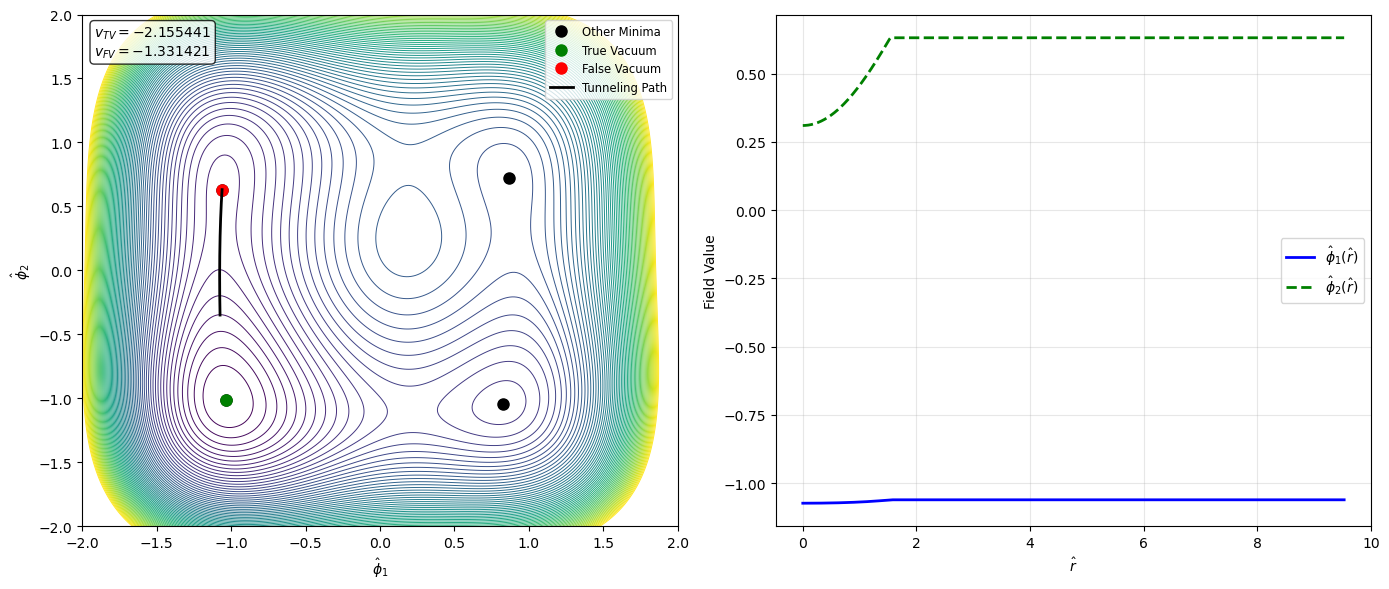

Runtime: 2.053337 seconds


In [11]:
#!/usr/bin/env python3
# _______________________ 2D dimensionless Coleman-like potential Cosmotransition(pathdeformation)_______________________
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from cosmoTransitions import pathDeformation as pd


class TwoDimColemanPotential:
    r"""
    Dimensionless potential:
        v(phihat1, phihat2) =
            (phihat1^2 - 1)^2
          + kappa1 (phihat1 - 1)
          + rho (phihat2^2 - 1)^2
          + rho*kappa2 (phihat2 - 1)
          + gamma phihat1^2 phihat2^2

    Input parameters:
        kappa1 : asymmetry parameter in phi1 direction
        rho    : relative weight of phi2 sector
        kappa2 : asymmetry parameter in phi2 direction
        gamma  : coupling between the two fields
    """

    def __init__(self, kappa1=0.7, rho=0.5, kappa2=0.6, gamma=0.15):
        self.kappa1 = kappa1
        self.rho    = rho
        self.kappa2 = kappa2
        self.gamma  = gamma

    # ---------------- Dimensionless potential ----------------
    def V(self, X):
        X = np.asanyarray(X)
        x, y = X[..., 0], X[..., 1]
        return (
            (x**2 - 1.0)**2
            + self.kappa1 * (x - 1.0)
            + self.rho * (y**2 - 1.0)**2
            + self.rho * self.kappa2 * (y - 1.0)
            + self.gamma * x**2 * y**2
        )

    def dV(self, X):
        X = np.asanyarray(X)
        x, y = X[..., 0], X[..., 1]

        dVdx = 4.0 * x * (x**2 - 1.0) + self.kappa1 + 2.0 * self.gamma * x * y**2
        dVdy = 4.0 * self.rho * y * (y**2 - 1.0) + self.rho * self.kappa2 + 2.0 * self.gamma * x**2 * y

        out = np.empty_like(X)
        out[..., 0] = dVdx
        out[..., 1] = dVdy
        return out

    def hessian_num(self, x, h=1e-5):
        x = np.asarray(x, dtype=float)
        H = np.zeros((2, 2), dtype=float)

        e1 = np.array([1.0, 0.0])
        e2 = np.array([0.0, 1.0])

        H[0, 0] = (self.V(x + h * e1) - 2 * self.V(x) + self.V(x - h * e1)) / h**2
        H[1, 1] = (self.V(x + h * e2) - 2 * self.V(x) + self.V(x - h * e2)) / h**2
        H[0, 1] = H[1, 0] = (
            self.V(x + h * e1 + h * e2)
            - self.V(x + h * e1 - h * e2)
            - self.V(x - h * e1 + h * e2)
            + self.V(x - h * e1 - h * e2)
        ) / (4 * h**2)
        return H

    def plot_contour(self, ax=None, xlim=(-2.0, 2.0), ylim=(-2.0, 2.0), ngrid=260):
        if ax is None:
            ax = plt.gca()

        x = np.linspace(xlim[0], xlim[1], ngrid)
        y = np.linspace(ylim[0], ylim[1], ngrid)
        X, Y = np.meshgrid(x, y)
        XY = np.stack([X, Y], axis=-1)
        Z = self.V(XY)

        levels = np.linspace(np.min(Z), np.percentile(Z, 92), 70)
        ax.contour(X, Y, Z, levels=levels, linewidths=0.7, cmap="viridis")
        ax.set_xlabel(r"$\hat{\phi}_1$")
        ax.set_ylabel(r"$\hat{\phi}_2$")

    def print_parameters(self):
        print("Dimensionless parameters:")
        print(f"  kappa1 = {self.kappa1}")
        print(f"  rho    = {self.rho}")
        print(f"  kappa2 = {self.kappa2}")
        print(f"  gamma  = {self.gamma}")


def refine_stationary_point(model, guess):
    res = minimize(model.V, guess, jac=model.dV, method="BFGS", tol=1e-12)
    return res.x, res.fun


def classify_point(model, x):
    H = model.hessian_num(x)
    eigs = np.linalg.eigvalsh(H)
    is_min = np.all(eigs > 1e-7)
    return is_min, eigs


def unique_points(points, tol=1e-4):
    uniq = []
    for p in points:
        if not any(np.linalg.norm(p - q) < tol for q in uniq):
            uniq.append(p)
    return uniq


def find_all_minima(model, xlim=(-2, 2), ylim=(-2, 2), ngrid=13):
    """
    Scan a grid of initial guesses, refine with local minimization,
    classify minima by Hessian, then remove duplicates.
    """
    xs = np.linspace(xlim[0], xlim[1], ngrid)
    ys = np.linspace(ylim[0], ylim[1], ngrid)

    candidates = []
    for x0 in xs:
        for y0 in ys:
            try:
                p, val = refine_stationary_point(model, np.array([x0, y0]))
                is_min, eigs = classify_point(model, p)
                if is_min:
                    candidates.append(p)
            except Exception:
                pass

    minima = unique_points(candidates, tol=1e-4)

    result = []
    for p in minima:
        val = model.V(p)
        result.append((p, val))

    result.sort(key=lambda item: item[1])
    return result


def reconstruct_field_profiles(Y):
    rhat = np.array(Y.profile1D.R)
    s_profile = np.array(Y.profile1D.Phi)

    path_points = np.array(Y.Phi)
    diffs = np.diff(path_points, axis=0)
    ds = np.sqrt(np.sum(diffs**2, axis=1))
    s_path = np.concatenate(([0.0], np.cumsum(ds)))

    phihat1_profile = np.interp(s_profile, s_path, path_points[:, 0])
    phihat2_profile = np.interp(s_profile, s_path, path_points[:, 1])

    return rhat, phihat1_profile, phihat2_profile


def choose_closest_false_vacuum(minima):
    """
    minima: sorted list [(point, value), ...], lowest value first.
    true vacuum = minima[0]
    false vacuum = local minimum with smallest Euclidean distance to true vacuum
                  among all other minima.
    """
    if len(minima) < 2:
        raise RuntimeError("Need at least two minima for tunneling.")

    true_vacuum, v_true = minima[0]

    candidates = []
    for p, val in minima[1:]:
        dist = np.linalg.norm(p - true_vacuum)
        candidates.append((dist, p, val))

    candidates.sort(key=lambda t: t[0])
    dist, false_vacuum, v_false = candidates[0]

    return true_vacuum, v_true, false_vacuum, v_false, dist


def makePlots():
    # ----------- input your dimensionless parameters here -----------
    model = TwoDimColemanPotential(
        kappa1=0.7,
        rho=0.5,
        kappa2= 0.95,
        gamma=0.2
    )

    model.print_parameters()

    print("\nSearching for all minima...")
    minima = find_all_minima(model, xlim=(-2, 2), ylim=(-2, 2), ngrid=17)

    if len(minima) == 0:
        raise RuntimeError("No minima found in the scan region.")

    print("\nList of minima (sorted by potential value):")
    for i, (p, val) in enumerate(minima):
        print(f"  minimum {i+1}:")
        print(f"    coordinates = ({p[0]: .8f}, {p[1]: .8f})")
        print(f"    value       = {val: .12f}")

    true_vacuum, v_true, false_vacuum, v_false, dist = choose_closest_false_vacuum(minima)

    print("\nChosen vacua for tunneling:")
    print(f"  true vacuum:")
    print(f"    coordinates = ({true_vacuum[0]: .8f}, {true_vacuum[1]: .8f})")
    print(f"    value       = {v_true: .12f}")
    print(f"  closest metastable minimum:")
    print(f"    coordinates = ({false_vacuum[0]: .8f}, {false_vacuum[1]: .8f})")
    print(f"    value       = {v_false: .12f}")
    print(f"    Delta v     = {v_false - v_true: .12f}")
    print(f"    distance    = {dist: .8f}")

    init_path = [true_vacuum, false_vacuum]

    print("\nRunning path deformation...")
    Y = pd.fullTunneling(init_path, model.V, model.dV)

    print(f"Reduced action from dimensionless potential = {Y.action: .12f}")

    rhat, phihat1_profile, phihat2_profile = reconstruct_field_profiles(Y)

    # ---------------- Plot 1: contour + all minima + chosen path ----------------
    plt.figure(figsize=(14, 6))

    ax1 = plt.subplot(121)
    model.plot_contour(ax1)

    all_pts = np.array([p for p, _ in minima])
    ax1.plot(all_pts[:, 0], all_pts[:, 1], 'ko', ms=8, label='Other Minima')

    ax1.plot(true_vacuum[0], true_vacuum[1], 'go', ms=8, label='True Vacuum')
    ax1.plot(false_vacuum[0], false_vacuum[1], 'ro', ms=8, label='False Vacuum')

    ax1.plot(Y.Phi[:, 0], Y.Phi[:, 1], 'k-', lw=2.0, label='Tunneling Path')

    info_text = (
        rf"$v_{{TV}} = {v_true:.6f}$" "\n"
        rf"$v_{{FV}} = {v_false:.6f}$"
    )

    ax1.text(
        0.02, 0.98, info_text,
        transform=ax1.transAxes,
        fontsize=10,
        verticalalignment='top',
        horizontalalignment='left',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='black')
    )

    ax1.legend(fontsize='small')

    # ---------------- Plot 2: field profiles ----------------
    ax2 = plt.subplot(122)
    ax2.plot(rhat, phihat1_profile, 'b-', lw=2, label=r'$\hat{\phi}_1(\hat r)$')
    ax2.plot(rhat, phihat2_profile, 'g--', lw=2, label=r'$\hat{\phi}_2(\hat r)$')
    ax2.set_xlabel(r"$\hat r$")
    ax2.set_ylabel("Field Value")
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    plt.savefig("figggggggure_name.png", dpi=300, bbox_inches='tight')
    plt.show()


if __name__ == "__main__":
    start = time.perf_counter()
    makePlots()
    end = time.perf_counter()
    print(f"Runtime: {end - start:.6f} seconds")